In [1]:
import torch
import numpy as np

import matplotlib.colors as colmat
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D

from mapie.conformity_scores import MultivariateResidualNormalisedScore

In [15]:
import torch

class Generator2D:
    def __init__(self, f, matrix_transform, noise_type='gaussian', noise_std=1.0):
        """
        Args:
            f (callable): Function f(X) -> (N, 2) (The conditional mean)
            matrix_transform (callable): Function A(X) -> (N, 2, 2). 
                                         Defines local noise shape and orientation.
            noise_type (str): 'gaussian', 'uniform', or 'exponential'
            noise_std (float): Global noise scaling factor
        """
        self.f = f
        self.matrix_transform = matrix_transform
        self.noise_type = noise_type
        self.noise_std = noise_std

    def _get_noise(self, n):
        """Generates a raw noise vector of shape (n, 2, 1)"""
        if self.noise_type == 'gaussian':
            noise = torch.randn(n, 2)
        elif self.noise_type == 'uniform':
            # Scale to [-1, 1] range
            noise = torch.rand(n, 2) * 2 - 1
        elif self.noise_type == 'exponential':
            noise = torch.distributions.Exponential(rate=1.0).sample((n, 2))
        else:
            raise ValueError(f"Unknown noise type: {self.noise_type}")
        
        # Reshape for matrix multiplication: (N, 2) -> (N, 2, 1)
        return (noise * self.noise_std).unsqueeze(2)

    def generate(self, n):
        """
        Generates n samples based on:
        X ~ U[-1, 1]
        Y = f(X) + A(X) @ Noise
        """
        # 1. Sample X from a uniform distribution [-1, 1]
        x = 2 * torch.rand(n, 1) - 1

        # 2. Compute conditional mean f(X) -> (n, 2)
        fx = self.f(x)

        # 3. Compute transformation matrix (root covariance) A(X) -> (n, 2, 2)
        A_x = self.matrix_transform(x)

        # 4. Generate raw noise -> (n, 2, 1)
        noise = self._get_noise(n)

        # 5. Apply transformation: (n, 2, 2) @ (n, 2, 1) -> (n, 2, 1)
        correlated_noise = torch.bmm(A_x, noise).squeeze(2)

        # 6. Final output: Y = mean + correlated noise
        y = fx + correlated_noise

        return x.numpy(), y.numpy()

    def generate_specific_y_given_x(self, x_tensor, n=1):
        """Returns n samples of Y for every provided X in x_tensor"""
        # Repeat X values to handle vectorization for multiple samples per input
        x_repeated = x_tensor.repeat_interleave(n, dim=0)
        
        fx = self.f(x_repeated)
        A_x = self.matrix_transform(x_repeated)
        noise = self._get_noise(x_repeated.shape[0])
        
        # Apply transformation and squeeze to (Total_N, 2)
        correlated_noise = torch.bmm(A_x, noise).squeeze(2)
        y_flat = fx + correlated_noise
        
        return y_flat
    
def matrix_transform_function(x):
    """
    Example transformation function that creates a 2x2 matrix 
    dependent on the input x.
    """
    n = x.shape[0]
    x_sq = x.squeeze()
    
    # Initialize identity matrices
    matrices = torch.eye(2).unsqueeze(0).repeat(n, 1, 1)
    
    # Dynamically adjust matrix components based on x
    matrices[:, 0, 0] = x_sq**2 + 0.5 
    matrices[:, 0, 1] = torch.sin(x_sq * 2)
    matrices[:, 1, 1] = torch.abs(x_sq) + 0.2

    return matrices

def circle_f(x):
    """Computes a mean vector that follows a circular/trigonometric path"""
    return torch.cat([torch.sin(x * 3), torch.cos(x * 3)], dim=1)

def plot_multiple_chdr_with_samples(tab_model, tab_colors, data_generator, level, x_range=(-1, 1), num_slices=12, n_samples=100):
    FS = 18

    fig = plt.figure(figsize=(8, 8), dpi=120) 
    ax = fig.add_subplot(111, projection='3d')
    
    xs = np.linspace(x_range[0], x_range[1], num_slices)
    
    levels = [level]
    linewidths = [2]
    
    for x_val in xs:
        x_tensor = np.array([x_val]).reshape(-1, 1)
        for idx, model in enumerate(tab_model):
            center, sigma = model.get_distribution(x_tensor)
            
            mu = center[0]
            cov = sigma[0]

            try:
                L = np.linalg.cholesky(cov)
            except np.linalg.LinAlgError:
                continue

            theta = np.linspace(0, 2*np.pi, 100)
            circle_points = np.stack([np.cos(theta), np.sin(theta)], axis=0)

            for r, col, lw in zip(levels, tab_colors[idx], linewidths):
                ellipse_points = mu[:, None] + L @ (r * circle_points)
                ax.plot(np.full_like(ellipse_points[0, :], x_val), ellipse_points[0, :], ellipse_points[1, :], color=col, linewidth=lw, alpha=0.8, zorder=2)

        x_tensor = np.array([x_val])
        samples = data_generator.generate_specific_y_given_x(torch.tensor(x_tensor, dtype=torch.float32).unsqueeze(0), n=n_samples)
        if hasattr(samples, 'detach'): samples = samples.detach().cpu().numpy()
        if samples.shape[0] != n_samples and samples.shape[1] == n_samples: samples = samples.T
        ax.scatter(np.full(n_samples, x_val), samples[:, 0], samples[:, 1], c='grey', marker='o', s=5, alpha=0.3, zorder=1)

    ax.set_xlabel(r'$X$', fontsize=FS, labelpad=15)
    ax.set_ylabel(r'$Y_1$', fontsize=FS, labelpad=15)
    
    ax.text(0.75, 16, 5, r'$Y_2$', fontsize=FS, fontweight='bold', ha='center')

    ax.set_xlim(x_range[0], x_range[1])
    z_limit = 7
    ax.set_zlim(-z_limit, z_limit)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.tick_params(axis='both', which='major', labelsize=FS)

    legend_elements = [
        Line2D([0], [0], color='black', lw=2, label=r'$C_\alpha(X)$'),
        Line2D([0], [0], marker='o', color='w', label=r'Samples from $\mathbb{P}_{Y|X}$',
               markerfacecolor='grey', markersize=8, alpha=0.5)
    ]
    ax.legend(handles=legend_elements, fontsize=FS, loc='upper left')

    ax.view_init(elev=20, azim=-60)
    

    plt.subplots_adjust(left=0.0, right=0.95, bottom=0.05, top=0.95)
    plt.show()

In [3]:
n_train = 20_000
n_test = 1_000
n_calibration = 1_000
n_stop = 1_000

dtype = torch.float32


# Initialize the generator with Exponential noise
generator = Generator2D(
    f=circle_f,
    matrix_transform=matrix_transform_function, 
    noise_std=1.0,
    noise_type="exponential"
)

x_samples, y_samples = generator.generate(100)

x_train, y_train = generator.generate(n_train)
x_stop, y_stop = generator.generate(n_stop)
x_calibration, y_calibration = generator.generate(n_calibration)
x_test, y_test = generator.generate(n_test)


In [22]:

class DummyTrainer:
    """A mock estimator to simulate the behavior of Trainer in unit tests. This trainer does not have a get_standardized_score function."""
    def __init__(self, covariance_trainer, output_dim):
        self.covariance_trainer = covariance_trainer
        self.output_dim = output_dim

    def fit(self, X, y, y_pred, **kwargs):
        self.fitted = True
        return self
    
    def predict(self, X):
        return self.covariance_trainer.predict(X)

    def get_distribution(self, X):
        n_samples = X.shape[0]
        # Returns dummy predictions and an identity covariance matrix per sample
        y_pred = self.predict(X)
        sigma = np.array([np.eye(self.output_dim) for _ in range(n_samples)])
        return y_pred, sigma

    def get_covariance_matrix(self, X):
        n_samples = X.shape[0]
        # Returns an identity covariance matrix per sample
        return np.array([np.eye(self.output_dim) for _ in range(n_samples)])
  

In [ ]:
calibrator = MultivariateResidualNormalisedScore()
calibrator.fit(x_train, y_train)
scores = calibrator.get_signed_conformity_scores(y_calibration, None, X=x_calibration)

n = len(scores)
alpha = 0.1
p = int(np.ceil((n+1)*(1-alpha)))
if p > n:
    raise ValueError("The number of calibration samples is too low to reach the desired alpha level.")
y_pred = calibrator.predict(x_train)
y_pred_cal = calibrator.predict(x_calibration)

scores_sorted = np.sort(scores)
level = scores_sorted[p]




In [23]:

calibrator_dummy = MultivariateResidualNormalisedScore(covariance_estimator=DummyTrainer(calibrator.covariance_estimator_, 2) )
calibrator_dummy.fit(x_train, y_train, y_pred=y_pred)
scores = calibrator_dummy.get_signed_conformity_scores(y_calibration, y_pred=y_pred_cal, X=x_calibration)

n = len(scores)
alpha = 0.1
p = int(np.ceil((n+1)*(1-alpha)))
if p > n:
    raise ValueError("The number of calibration samples is too low to reach the desired alpha level.")

scores_sorted = np.sort(scores)
level = scores_sorted[p]

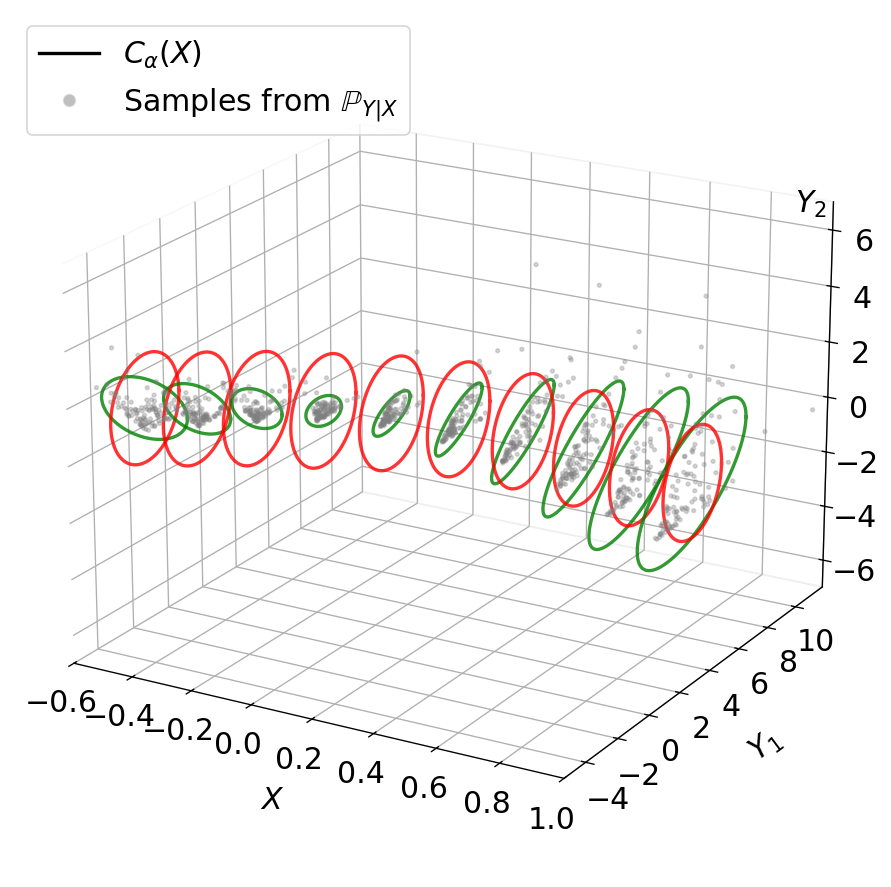

In [24]:
plot_multiple_chdr_with_samples([calibrator.covariance_estimator_, calibrator_dummy.covariance_estimator_], ['green', 'red'],  generator, level, num_slices=10, x_range=(-0.6, 1))

In [32]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from numpy.typing import NDArray
from sklearn.neural_network import MLPRegressor

from mapie.metrics.regression import regression_coverage_score
from mapie.regression import SplitConformalRegressor
from mapie.utils import train_conformalize_test_split

from mapie.conformity_scores import MultivariateResidualNormalisedScore

RANDOM_STATE = 1

confidence_level = 0.95
mapie_stand = SplitConformalRegressor(
    conformity_score = MultivariateResidualNormalisedScore(mode= "low_rank"),
    confidence_level=confidence_level, 
    prefit=False
)



In [ ]:
n_train = 20_000
n_test = 1_000
n_calibration = 1_000
n_stop = 1_000

dtype = torch.float32


# Initialize the generator with Exponential noise
generator = Generator2D(
    f=circle_f,
    matrix_transform=matrix_transform_function, 
    noise_std=1.0,
    noise_type="exponential"
)

x_samples, y_samples = generator.generate(100)

x_train, y_train = generator.generate(n_train)
x_stop, y_stop = generator.generate(n_stop)
x_calibration, y_calibration = generator.generate(n_calibration)
x_test, y_test = generator.generate(n_test)

y_train_1d = y_train[:, 0]
y_stop_1d = y_stop[:, 0]
y_calibration_1d = y_calibration[:, 0]
y_test_1d = y_test[:, 0]

mapie_stand._conformity_score.fit(x_train, y_train, num_epochs=1)  ### THIS SHOULD BE DONE WITH THE mapie_stand obj and therefore avoid the following line
mapie_stand._is_fitted = True
mapie_stand.conformalize(x_calibration, y_calibration)

/Users/sbraun/Desktop/Inria/MAPIE/MAPIE/mapie/utils.py:1445: UserWarning: Estimator does not appear fitted. At least one of the expected attributes is missing in : ['n_features_in_', 'classes_', 'coef_', 'feature_names_in_', 'tree_', 'estimators_', 'fitted_'].
  warnings.warn(


ValueError: y should be a 1d array, got an array of shape (1000, 2) instead.